In [1]:
#EDA

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 6)


In [6]:
import os

os.chdir(r"C:\Users\Rebeca\ONLINE_DS_THEBRIDGE-REBECA_BORRERO\DS-Online\Eda")


In [7]:
## Cargamos los datasets
# Consolas
df = pd.read_csv("best_selling_game_consoles.csv")

# Videojuegos
games_df = pd.read_csv("videogames_sales.csv")



In [ ]:
## Limpiamos el dato consolas

df.columns = (
    df.columns
    .str.lower()
    .str.replace(" ", "_")
)

df.rename(columns={"units_sold_(million)": "units_sold_million"}, inplace=True)

df["discontinuation_year"] = df["discontinuation_year"].replace(0, np.nan)


In [9]:
## Limpiamos el dato videojueguiiil

games_df.columns = (
    games_df.columns
    .str.lower()
    .str.replace(" ", "_")
)

num_cols = [
    "critic_score", "user_score", "total_shipped",
    "global_sales", "na_sales", "pal_sales",
    "jp_sales", "other_sales", "year"
]

for col in num_cols:
    games_df[col] = pd.to_numeric(games_df[col], errors="coerce")


In [13]:
# 1) Renombrar console_name -> platform
df = df.rename(columns={"console_name": "platform"})

# 2) Aplicar el mapeo de plataformas
df["platform"] = df["platform"].replace(platform_map)

df.columns


Index(['platform', 'type', 'company', 'released_year', 'discontinuation_year',
       'units_sold_million', 'remarks'],
      dtype='object')

In [14]:
## Vamos a apañar el tema de los nombres para que no haya drama
platform_map = {
    # Sony
    "PlayStation": "PS",
    "PlayStation 2": "PS2",
    "PlayStation 3": "PS3",
    "PlayStation 4": "PS4",
    "PlayStation 5": "PS5",

    # Nintendo
    "Nintendo Entertainment System": "NES",
    "Super Nintendo Entertainment System": "SNES",
    "Nintendo 64": "N64",
    "GameCube": "GC",
    "Wii": "Wii",
    "Wii U": "WiiU",
    "Nintendo Switch": "Switch",
    "Game Boy": "GB",
    "Game Boy Color": "GBC",
    "Game Boy Advance": "GBA",
    "Nintendo DS": "DS",
    "Nintendo 3DS": "3DS",

    # Microsoft
    "Xbox": "Xbox",
    "Xbox 360": "X360",
    "Xbox One": "XOne",

    # Sega
    "Sega Saturn": "SAT",
    "Dreamcast": "DC",

    # Atari
    "Atari 2600": "2600",
    "Atari 5200": "5200",
    "Atari 7800": "7800"
}

df["platform"] = df["platform"].replace(platform_map)


In [15]:
## Ahora voy a mezclarlo todo en el caldero a ver si no la lío

merged_df = games_df.merge(
    df,
    on="platform",
    how="left",
    indicator=True
)

merged_consoles = merged_df[merged_df["_merge"] == "both"].copy()


In [16]:
## Ya de paso vamos a definir las generaciones

generation_map = {
    # 5ª generación
    "PS": 5, "N64": 5, "SAT": 5,

    # 6ª generación
    "PS2": 6, "GC": 6, "Xbox": 6, "DC": 6,

    # 7ª generación
    "PS3": 7, "X360": 7, "Wii": 7,

    # 8ª generación
    "PS4": 8, "XOne": 8, "Switch": 8,

    # 9ª generación
    "PS5": 9
}

merged_consoles["generation"] = merged_consoles["platform"].map(generation_map)


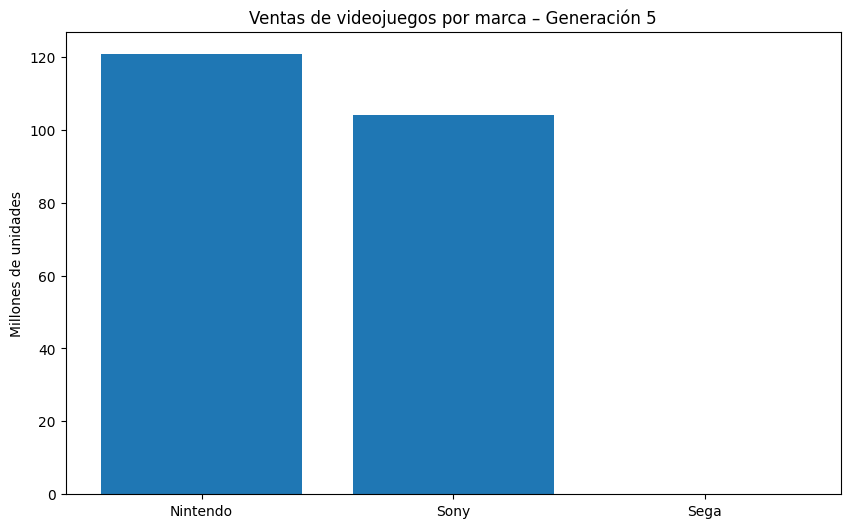

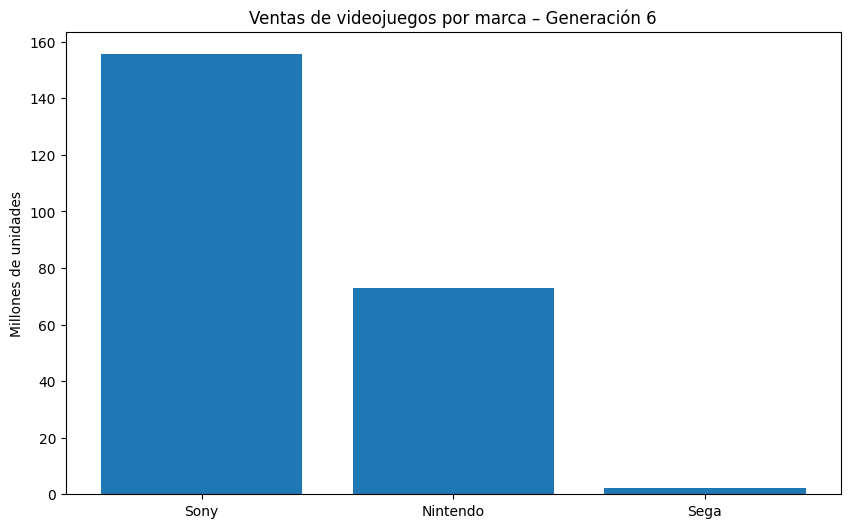

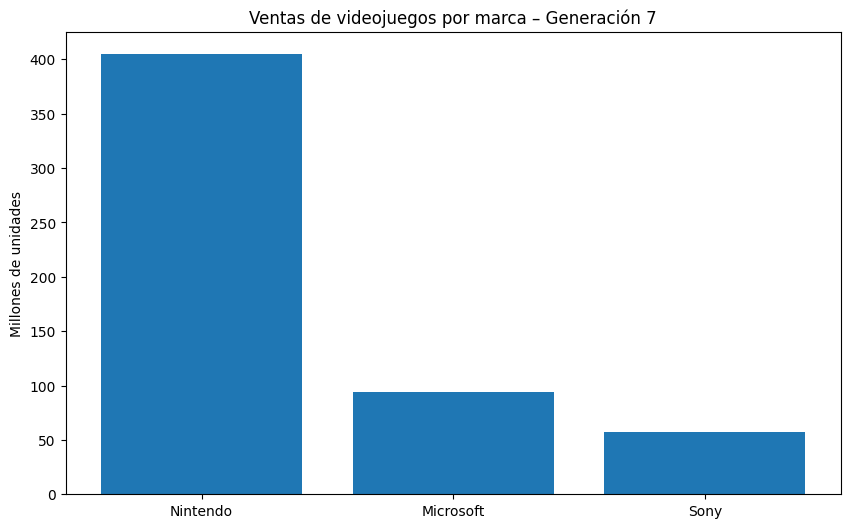

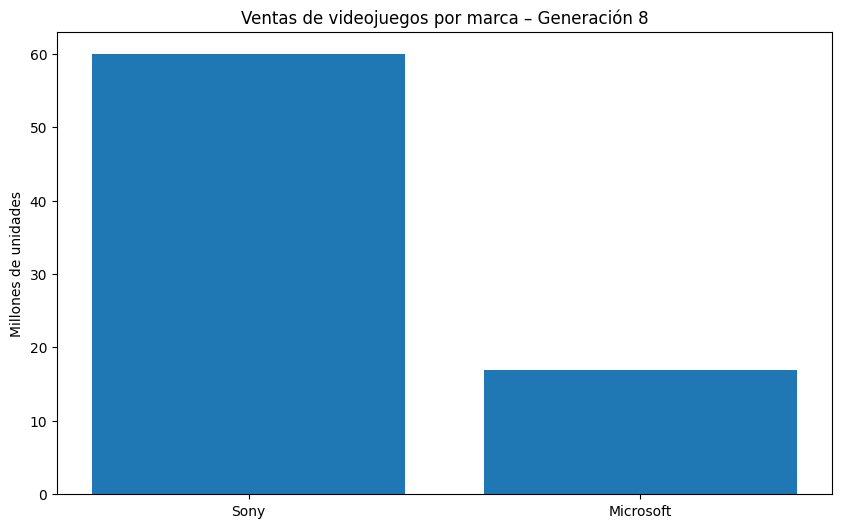

In [17]:
## Y ahora podemos comprobar si soy un fraude o qué QUÉ NERVIOS

gen_company_sales = (
    merged_consoles
    .groupby(["generation", "company"])["total_shipped"]
    .sum()
    .reset_index()
)

for gen in sorted(gen_company_sales["generation"].dropna().unique()):
    subset = (
        gen_company_sales[gen_company_sales["generation"] == gen]
        .sort_values("total_shipped", ascending=False)
    )

    plt.figure()
    plt.bar(subset["company"], subset["total_shipped"])
    plt.title(f"Ventas de videojuegos por marca – Generación {int(gen)}")
    plt.ylabel("Millones de unidades")
    plt.show()




In [ ]:
## Miau, según la gráfica puedo seguir siendo niña sony

In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1) Asegurar carpeta correcta
os.chdir(r"C:\Users\Rebeca\ONLINE_DS_THEBRIDGE-REBECA_BORRERO\DS-Online\Eda")

# 2) Cargar datasets
df = pd.read_csv("best_selling_game_consoles.csv")
games_df = pd.read_csv("videogames_sales.csv")

# 3) Normalizar columnas
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
games_df.columns = games_df.columns.str.strip().str.lower().str.replace(" ", "_")

# 4) Renombrar para poder hacer merge
if "console_name" in df.columns:
    df = df.rename(columns={"console_name": "platform"})

# 5) Asegurar tipos numéricos en videojuegos
num_cols = [
    "critic_score", "user_score", "total_shipped",
    "global_sales", "na_sales", "pal_sales",
    "jp_sales", "other_sales", "year"
]
for col in num_cols:
    if col in games_df.columns:
        games_df[col] = pd.to_numeric(games_df[col], errors="coerce")

# 6) Mapeo de plataformas (nombres completos -> códigos)
platform_map = {
    # Sony
    "PlayStation": "PS",
    "PlayStation 2": "PS2",
    "PlayStation 3": "PS3",
    "PlayStation 4": "PS4",
    "PlayStation 5": "PS5",

    # Nintendo
    "Nintendo Entertainment System": "NES",
    "Super Nintendo Entertainment System": "SNES",
    "Nintendo 64": "N64",
    "GameCube": "GC",
    "Wii": "Wii",
    "Wii U": "WiiU",
    "Nintendo Switch": "Switch",
    "Game Boy": "GB",
    "Game Boy Color": "GBC",
    "Game Boy Advance": "GBA",
    "Nintendo DS": "DS",
    "Nintendo 3DS": "3DS",

    # Microsoft
    "Xbox": "Xbox",
    "Xbox 360": "X360",
    "Xbox One": "XOne",

    # Sega
    "Sega Saturn": "SAT",
    "Dreamcast": "DC",

    # Atari
    "Atari 2600": "2600",
    "Atari 5200": "5200",
    "Atari 7800": "7800"
}

df["platform"] = df["platform"].replace(platform_map)

# 7) Merge y filtrado
merged_df = games_df.merge(df, on="platform", how="left", indicator=True)
merged_consoles = merged_df[merged_df["_merge"] == "both"].copy()

print("OK ✅")
print("df:", df.shape, "| games_df:", games_df.shape, "| merged_consoles:", merged_consoles.shape)

# 8) Preparar ventas por plataforma y año (para ciclo de vida)
platform_year_sales = (
    merged_consoles
    .groupby(["platform", "year"])["total_shipped"]
    .sum()
    .reset_index()
)


OK ✅
df: (51, 7) | games_df: (55792, 16) | merged_consoles: (25606, 23)


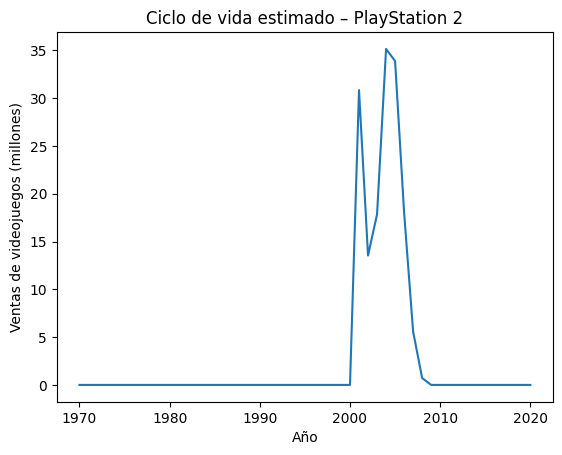

In [4]:
ps2 = platform_year_sales[platform_year_sales["platform"] == "PS2"]

plt.plot(ps2["year"], ps2["total_shipped"])
plt.title("Ciclo de vida estimado – PlayStation 2")
plt.xlabel("Año")
plt.ylabel("Ventas de videojuegos (millones)")
plt.show()


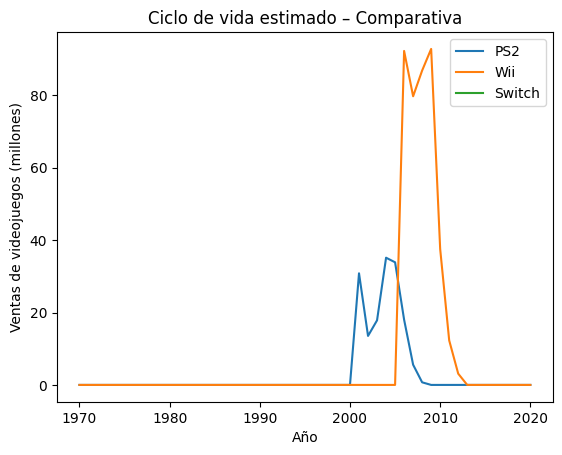

In [6]:
##Si comparo entre consolitas
def plot_lifecycle(platform_code, label=None):
    data = platform_year_sales[platform_year_sales["platform"] == platform_code].sort_values("year")
    plt.plot(data["year"], data["total_shipped"], label=label or platform_code)

plt.figure()
plot_lifecycle("PS2")
plot_lifecycle("Wii")
plot_lifecycle("Switch")
plt.title("Ciclo de vida estimado – Comparativa")
plt.xlabel("Año")
plt.ylabel("Ventas de videojuegos (millones)")
plt.legend()
plt.show()


In [7]:
## Plataformas por ventas de juegos
sales_by_platform = (
    merged_consoles.groupby("platform")["total_shipped"]
    .sum()
    .sort_values(ascending=False)
)

sales_by_platform.head(15)


platform
Wii     404.71
DS      354.06
3DS     232.76
GB      211.35
PS2     155.59
N64     120.69
PS      104.12
GBA      95.23
X360     94.35
GC       72.99
WiiU     60.03
PS4      59.91
PS3      57.15
GBC      21.98
XOne     16.87
Name: total_shipped, dtype: float64

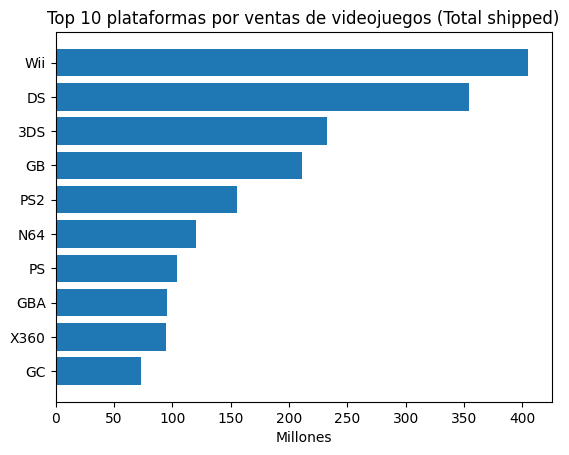

In [8]:
top10 = sales_by_platform.head(10)
plt.figure()
plt.barh(top10.index, top10.values)
plt.title("Top 10 plataformas por ventas de videojuegos (Total shipped)")
plt.xlabel("Millones")
plt.gca().invert_yaxis()
plt.show()


In [9]:
##exclusivos de nintendo más vendidos
exclusive_nintendo = (
    merged_consoles[
        (merged_consoles["company"] == "Nintendo") &
        (merged_consoles["publisher"] == "Nintendo")
    ]
    .sort_values("total_shipped", ascending=False)
    [["name", "platform", "year", "total_shipped"]]
    .head(15)
)

exclusive_nintendo


,name,platform,year,total_shipped
0,Wii Sports,Wii,2006.0,82.86
2,Mario Kart Wii,Wii,2008.0,37.14
4,Wii Sports Resort,Wii,2009.0,33.09
5,Pokemon Red / Green / Blue Version,GB,1998.0,31.38
6,New Super Mario Bros.,DS,2006.0,30.80
7,Tetris,GB,1989.0,30.26
8,New Super Mario Bros. Wii,Wii,2009.0,30.22
11,Wii Play,Wii,2007.0,28.02
13,Nintendogs,DS,2005.0,23.96
14,Mario Kart DS,DS,2005.0,23.60


In [12]:
exclusive_playstation = (
    merged_consoles[
        (merged_consoles["company"] == "Sony") &
        (merged_consoles["publisher"].str.contains("Sony", na=False))
    ]
    .sort_values("total_shipped", ascending=False)
    [["name", "platform", "year", "total_shipped"]]
    .head(15)
)

exclusive_playstation


,name,platform,year,total_shipped
38,Gran Turismo 3: A-Spec,PS2,2001.0,14.89
66,Gran Turismo 5,PS3,2010.0,11.95
69,Gran Turismo 4,PS2,2005.0,11.76
77,Gran Turismo,PS,1998.0,10.85
84,Horizon: Zero Dawn,PS4,2017.0,10.00
90,Final Fantasy VII,PS,1997.0,9.90
95,Gran Turismo 2,PS,1999.0,9.37
102,Marvel's Spider-Man,PS4,2018.0,9.00
108,Uncharted 4: A Thief's End,PS4,2016.0,8.70
149,Crash Bandicoot,PS,1996.0,6.82


In [ ]:
## exclusivos de xbox casi me da algo cuando he visto el viva piñata

exclusive_xbox = (
    merged_consoles[
        (merged_consoles["company"] == "Microsoft") &
        (
            merged_consoles["publisher"].str.contains(
                "Microsoft|Xbox|343|Turn 10|The Coalition",
                case=False,
                na=False
            )
        )
    ]
    .sort_values("total_shipped", ascending=False)
    [["name", "platform", "year", "total_shipped"]]
    .head(15)
)

exclusive_xbox


,name,platform,year,total_shipped
12,Kinect Adventures!,X360,2010.0,24.00
43,Halo 3,X360,2007.0,14.50
56,Minecraft,X360,2013.0,13.00
255,Gears of War,X360,2006.0,5.00
256,Gears of War 2,X360,2008.0,5.00
258,Halo 5: Guardians,XOne,2015.0,5.00
451,Fable II,X360,2008.0,3.50
562,Gears of War 3,X360,2011.0,3.00
563,Kinect Sports,X360,2010.0,3.00
695,Dead Rising 3,XOne,2013.0,2.60


In [10]:
## valoraciones versus ventas

subset_scores = games_df[["critic_score", "user_score", "total_shipped"]].dropna()
subset_scores.corr()


,critic_score,user_score,total_shipped
critic_score,1.000000,0.631234,0.140261
user_score,0.631234,1.000000,-0.042074
total_shipped,0.140261,-0.042074,1.000000


In [11]:
## géneros top por plataforma

genre_platform = (
    merged_consoles.groupby(["platform", "genre"])["total_shipped"]
    .sum()
    .reset_index()
)

def top_genres(platform_code, n=5):
    return genre_platform[genre_platform["platform"] == platform_code] \
        .sort_values("total_shipped", ascending=False) \
        .head(n)

top_genres("Wii", 7)


,platform,genre,total_shipped
220,Wii,Sports,174.58
214,Wii,Platform,76.54
211,Wii,Misc,63.63
216,Wii,Racing,37.14
209,Wii,Fighting,14.43
208,Wii,Adventure,12.18
218,Wii,Shooter,9.72


In [13]:
## a ver si sé comparar play vs nintendo

top_exclusives_compare = pd.concat(
    [
        exclusive_nintendo.assign(company="Nintendo"),
        exclusive_playstation.assign(company="Sony")
    ]
)

top_exclusives_compare


,name,platform,year,total_shipped,company
0,Wii Sports,Wii,2006.0,82.86,Nintendo
2,Mario Kart Wii,Wii,2008.0,37.14,Nintendo
4,Wii Sports Resort,Wii,2009.0,33.09,Nintendo
5,Pokemon Red / Green / Blue Version,GB,1998.0,31.38,Nintendo
6,New Super Mario Bros.,DS,2006.0,30.80,Nintendo
7,Tetris,GB,1989.0,30.26,Nintendo
8,New Super Mario Bros. Wii,Wii,2009.0,30.22,Nintendo
11,Wii Play,Wii,2007.0,28.02,Nintendo
13,Nintendogs,DS,2005.0,23.96,Nintendo
14,Mario Kart DS,DS,2005.0,23.60,Nintendo


In [15]:
## exclusivos vs third party
def exclusivity_flag(row):
    if row["company"] == "Nintendo" and row["publisher"] == "Nintendo":
        return "Exclusive"
    if row["company"] == "Sony" and "Sony" in str(row["publisher"]):
        return "Exclusive"
    if row["company"] == "Microsoft" and any(
        x in str(row["publisher"]) for x in ["Microsoft", "Xbox", "343", "Turn 10", "Coalition"]
    ):
        return "Exclusive"
    return "Third-party"

merged_consoles["exclusivity"] = merged_consoles.apply(exclusivity_flag, axis=1)


In [16]:
exclusivity_sales = (
    merged_consoles
    .groupby(["company", "exclusivity"])["total_shipped"]
    .sum()
    .reset_index()
)

exclusivity_sales


,company,exclusivity,total_shipped
0,Atari,Third-party,7.70
1,Microsoft,Exclusive,85.12
2,Microsoft,Third-party,26.10
3,Nintendo,Exclusive,1455.28
4,Nintendo,Third-party,118.52
5,Sega,Third-party,2.34
6,Sony,Exclusive,152.30
7,Sony,Third-party,224.47


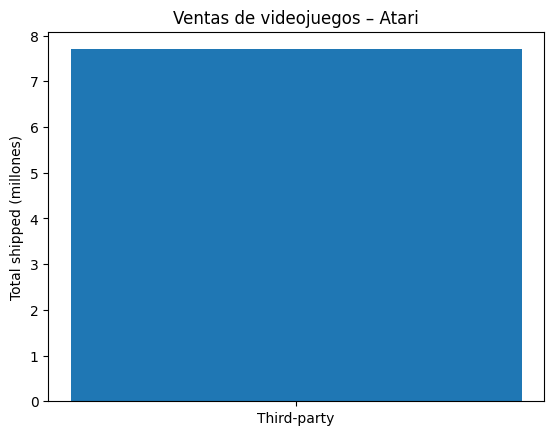

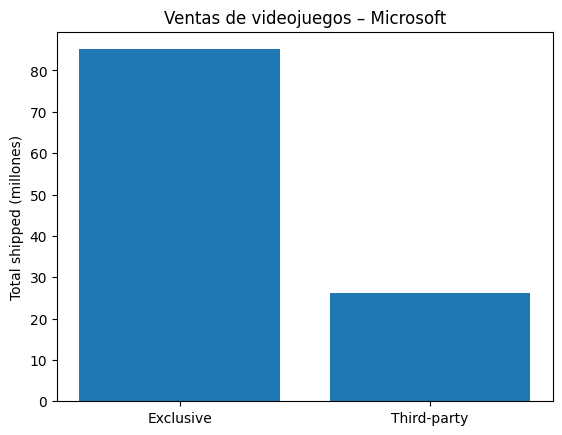

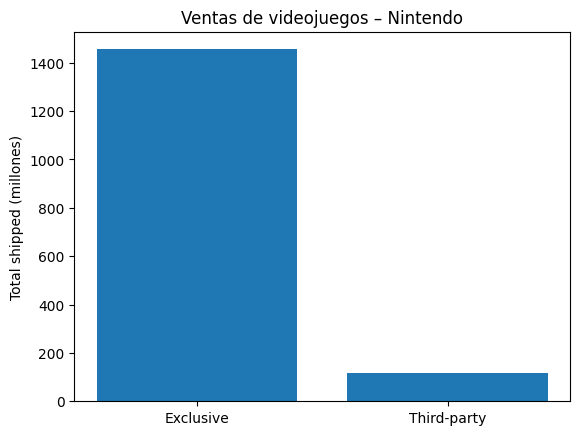

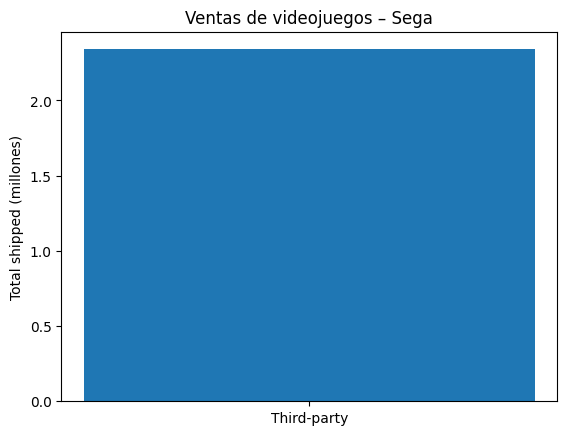

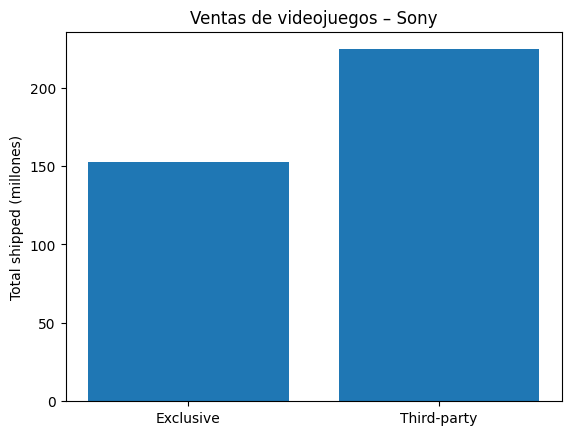

In [17]:
for company in exclusivity_sales["company"].unique():
    subset = exclusivity_sales[exclusivity_sales["company"] == company]
    plt.figure()
    plt.bar(subset["exclusivity"], subset["total_shipped"])
    plt.title(f"Ventas de videojuegos – {company}")
    plt.ylabel("Total shipped (millones)")
    plt.show()
